In [1]:
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# DATA

## data liz en renske juist maken.

In [2]:
def split_functie_csv(filepath,i,j, tijd_column="Time (s)"):
    df = pd.read_csv(filepath) 
    map_output = filepath + "_split"
    os.makedirs(map_output, exist_ok=True)
    df['second'] = df[tijd_column].astype(int)
    for second, group in df.groupby('second'):
        output_file = f"Raw_data/{i}_{j}kg_second_{second}.csv"
        group.drop(columns=['second'], inplace=True)
        group.to_csv(output_file, index=False)
        print(f"Saved {second}.csv with {len(group)} rows.")

In [3]:
for i in ['asfalt', 'zand', 'grass', 'stenen']:
    for j in [0, 1, 2, 3, 5]:
        split_functie_csv(f"Raw_data\{i}_{j}kg\Raw Data.csv",i,j)


<string>:3: SyntaxWarning: invalid escape sequence '\{'
<>:3: SyntaxWarning: invalid escape sequence '\{'
<>:3: SyntaxWarning: invalid escape sequence '\R'
<string>:3: SyntaxWarning: invalid escape sequence '\{'
<>:3: SyntaxWarning: invalid escape sequence '\{'
<>:3: SyntaxWarning: invalid escape sequence '\R'
C:\Users\laure\AppData\Local\Temp\ipykernel_23828\3584152991.py:3: SyntaxWarning: invalid escape sequence '\{'
  split_functie_csv(f"Raw_data\{i}_{j}kg\Raw Data.csv",i,j)
C:\Users\laure\AppData\Local\Temp\ipykernel_23828\3584152991.py:3: SyntaxWarning: invalid escape sequence '\R'
  split_functie_csv(f"Raw_data\{i}_{j}kg\Raw Data.csv",i,j)


Saved 0.csv with 101 rows.
Saved 1.csv with 100 rows.
Saved 2.csv with 101 rows.
Saved 3.csv with 100 rows.
Saved 4.csv with 101 rows.
Saved 5.csv with 100 rows.
Saved 6.csv with 101 rows.
Saved 7.csv with 100 rows.
Saved 8.csv with 100 rows.
Saved 9.csv with 101 rows.
Saved 10.csv with 100 rows.
Saved 11.csv with 101 rows.
Saved 12.csv with 100 rows.
Saved 13.csv with 101 rows.
Saved 14.csv with 83 rows.
Saved 0.csv with 100 rows.
Saved 1.csv with 101 rows.
Saved 2.csv with 100 rows.
Saved 3.csv with 101 rows.
Saved 4.csv with 100 rows.
Saved 5.csv with 101 rows.
Saved 6.csv with 100 rows.
Saved 7.csv with 101 rows.
Saved 8.csv with 100 rows.
Saved 9.csv with 101 rows.
Saved 10.csv with 100 rows.
Saved 11.csv with 101 rows.
Saved 12.csv with 100 rows.
Saved 13.csv with 100 rows.
Saved 14.csv with 30 rows.
Saved 0.csv with 101 rows.
Saved 1.csv with 100 rows.
Saved 2.csv with 100 rows.
Saved 3.csv with 101 rows.
Saved 4.csv with 100 rows.
Saved 5.csv with 101 rows.
Saved 6.csv with 100

In [4]:
meta = pd.read_excel("Raw_data/documentation_data.xlsx")
meta.head()

,sample_name,road_type,backpack_weight_kg,windspeed_km/h,bike_weight_kg,phone_position
0,grass_0kg,grass,0.75,21,21,handlebar
1,grass_1kg,grass,1.75,21,21,handlebar
2,grass_2kg,grass,2.75,5,21,handlebar
3,grass_3kg,grass,3.75,21,21,handlebar
4,grass_5kg,grass,5.75,21,21,handlebar


## inladen data in en in juiste vorm zetten

In [5]:
all_data = []
meta = pd.read_excel('Raw_data/documentation_data.xlsx')
        
for i in range(len(meta)):
    
    file_name = meta.loc[i, 'sample_name']
    df = pd.read_csv(f'Raw_data/{file_name}/Raw Data.csv')
    meta_row = meta[meta['sample_name'] == file_name].iloc[0]
    
    road_type = meta_row['road_type']
    weight = meta_row['backpack_weight_kg']
    weather = meta_row['phone_position']
    df['second'] = df['Time (s)'].astype(int)
   # df['file'] = f'{file_name}second_{df['second'].astype(str)}'
    df['roadtype'] = road_type
    df['weight'] = weight
    df['weather'] = weather
    df['makers'] = 'Liz & Renske'
    df['weather'] = df['roadtype'].map({
        'asphalt': 'Damp',
        'sand': 'Wet',
        'grass': 'Damp',
        'bricks': 'Damp'
    })
    df['file'] = file_name + '_second_' + df['second'].astype(str)
    
    all_data.append(df)
    for sec, group in df.groupby('second'):
        filename = f"{file_name}_second_{sec}.csv"
        print(filename)



result = pd.concat(all_data, ignore_index=True)
result.rename(columns={'Time (s)': 'time', 'Linear Acceleration x (m/s^2)': 'x', 'Linear Acceleration y (m/s^2)': 'y', 'Linear Acceleration z (m/s^2)': 'z','Absolute acceleration (m/s^2)': 'abs'}, inplace=True)

# opslaan
result.to_csv("output.csv", index=False)
dfLR = pd.read_csv("output.csv")
dfLR.head()

grass_0kg_second_0.csv
grass_0kg_second_1.csv
grass_0kg_second_2.csv
grass_0kg_second_3.csv
grass_0kg_second_4.csv
grass_0kg_second_5.csv
grass_0kg_second_6.csv
grass_0kg_second_7.csv
grass_0kg_second_8.csv
grass_0kg_second_9.csv
grass_0kg_second_10.csv
grass_0kg_second_11.csv
grass_0kg_second_12.csv
grass_1kg_second_0.csv
grass_1kg_second_1.csv
grass_1kg_second_2.csv
grass_1kg_second_3.csv
grass_1kg_second_4.csv
grass_1kg_second_5.csv
grass_1kg_second_6.csv
grass_1kg_second_7.csv
grass_1kg_second_8.csv
grass_1kg_second_9.csv
grass_1kg_second_10.csv
grass_1kg_second_11.csv
grass_1kg_second_12.csv
grass_2kg_second_0.csv
grass_2kg_second_1.csv
grass_2kg_second_2.csv
grass_2kg_second_3.csv
grass_2kg_second_4.csv
grass_2kg_second_5.csv
grass_2kg_second_6.csv
grass_2kg_second_7.csv
grass_2kg_second_8.csv
grass_2kg_second_9.csv
grass_2kg_second_10.csv
grass_2kg_second_11.csv
grass_2kg_second_12.csv
grass_2kg_second_13.csv
grass_3kg_second_0.csv
grass_3kg_second_1.csv
grass_3kg_second_2.csv
g

,time,x,y,z,abs,second,roadtype,weight,weather,makers,file
0,0.000648,0.048065,0.005317,-0.005597,0.048681,0,grass,0.75,Damp,Liz & Renske,grass_0kg_second_0
1,0.010602,0.048102,-0.003253,0.017100,0.051154,0,grass,0.75,Damp,Liz & Renske,grass_0kg_second_0
2,0.020555,0.050894,-0.011365,0.020154,0.055907,0,grass,0.75,Damp,Liz & Renske,grass_0kg_second_0
3,0.030509,0.045618,-0.016344,0.019934,0.052398,0,grass,0.75,Damp,Liz & Renske,grass_0kg_second_0
4,0.040463,0.034196,-0.003633,0.001251,0.034412,0,grass,0.75,Damp,Liz & Renske,grass_0kg_second_0


In [6]:
all_data = []
meta = pd.read_csv('data_verzameling_laurence_doris_ - kopie/csv_with_other_factors.csv')


for i in range(len(meta)):
    file_name = meta.loc[i, 'cut_file']
    df = pd.read_csv(f'data_verzameling_laurence_doris_ - kopie/{file_name}')
    meta_row = meta[meta['cut_file'] == file_name].iloc[0]
    
    road_type = meta_row['road_types']
    weight = meta_row['backpack_weight(kg)']
    weather = meta_row['weather (degrees)']
    
    df['file'] = file_name
    df['roadtype'] = road_type
    df['weight'] = weight
    df['weather'] = weather
    df['makers'] = 'Laurence & Doris'
    df['second'] = df['Time (s)'].astype(int)

    df['weather'] = df['roadtype'].map({
        'Asphalts': 'Dry',
        'Wood': 'Dry',
        'Grass': 'Damp',
        'Bricks': 'Dry'
    })
    
    all_data.append(df)
    

result = pd.concat(all_data, ignore_index=True)
result.rename(columns={'Time (s)': 'time', 'Linear Acceleration x (m/s^2)': 'x', 'Linear Acceleration y (m/s^2)': 'y', 'Linear Acceleration z (m/s^2)': 'z','Absolute acceleration (m/s^2)': 'abs'}, inplace=True)

# opslaan
result.to_csv("output.csv", index=False)
dfLD = pd.read_csv("output.csv")
dfLD.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,second
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,Asphalts,0.0,Dry,Laurence & Doris,0
1,0.015820,-0.783787,-0.178738,0.051753,0.805572,Asfalt_0_second_0.csv,Asphalts,0.0,Dry,Laurence & Doris,0
2,0.025869,-0.979383,-0.414515,0.126817,1.071026,Asfalt_0_second_0.csv,Asphalts,0.0,Dry,Laurence & Doris,0
3,0.035918,-0.206056,0.006505,0.141417,0.250000,Asfalt_0_second_0.csv,Asphalts,0.0,Dry,Laurence & Doris,0
4,0.045967,-0.170787,0.299400,0.056795,0.349334,Asfalt_0_second_0.csv,Asphalts,0.0,Dry,Laurence & Doris,0


In [7]:
all_data = []
meta = pd.read_csv('1sec_cuts/labels_overview.csv', sep=';')


for i in range(len(meta)):
    file_name = meta.loc[i, 'file_name']
    df = pd.read_csv(f'1sec_cuts/{file_name}')
    meta_row = meta[meta['file_name'] == file_name].iloc[0]
    
    road_type = meta_row['road_type']
    weight = meta_row['backpack_weight_kg']
    weather = meta_row['Weather Conditions']
    df['second'] = df['time_s'].astype(int)
    df['file'] = file_name
    df['roadtype'] = road_type
    df['weight'] = weight
    df['weather'] = weather
    df['makers'] = 'Servé & Jasper'
    
    all_data.append(df)
    

result = pd.concat(all_data, ignore_index=True)
result.rename(columns={'time_s': 'time', 'acc_x_ms2': 'x', 'acc_y_ms2': 'y', 'acc_z_ms2': 'z','acc_abs_ms2': 'abs'}, inplace=True)

# opslaan
result.to_csv("output.csv", index=False)
dfJJ = pd.read_csv("output.csv")
dfJJ.head()

,time,x,y,z,abs,second,file,roadtype,weight,weather,makers
0,0.000000,0.002008,0.047438,-0.010847,0.048704,0,sample_01_Asfalt_combo1_cut01.csv,Asfalt,0.0,Dry,Servé & Jasper
1,0.008087,-0.087754,0.035832,0.017712,0.096428,0,sample_01_Asfalt_combo1_cut01.csv,Asfalt,0.0,Dry,Servé & Jasper
2,0.016083,-0.059583,0.038330,0.024818,0.075068,0,sample_01_Asfalt_combo1_cut01.csv,Asfalt,0.0,Dry,Servé & Jasper
3,0.024077,-0.024203,0.028852,0.019957,0.042620,0,sample_01_Asfalt_combo1_cut01.csv,Asfalt,0.0,Dry,Servé & Jasper
4,0.032074,-0.027113,0.014605,0.034250,0.046060,0,sample_01_Asfalt_combo1_cut01.csv,Asfalt,0.0,Dry,Servé & Jasper


In [8]:
all_data = []
meta = pd.read_csv('segmented_data/segment_metadata.csv')


for i in range(len(meta)):
    file_name = meta.loc[i, 'segment_file']
    df = pd.read_csv(f'segmented_data/{file_name}')
    meta_row = meta[meta['segment_file'] == file_name].iloc[0]
    
    road_type = meta_row['road_type']
    weight = meta_row['backpack_weight']
    weather = meta_row['surface_condition']
    
    df['file'] = file_name
    df['roadtype'] = road_type
    df['weight'] = weight
    df['weather'] = weather
    df['makers'] = 'Hala & Ismeal'
    
    all_data.append(df)
    


result = pd.concat(all_data, ignore_index=True)
#result.rename(columns={'Time (s)': 'time', 'Linear Acceleration x (m/s^2)': 'x', 'Linear Acceleration y (m/s^2)': 'y', 'Linear Acceleration z (m/s^2)': 'z'}, inplace=True)
# opslaan
result.to_csv("output.csv", index=False)
df_HI = pd.read_csv("output.csv")
df_HI.head()

,time,x,y,z,file,roadtype,weight,weather,makers
0,0.008924,-0.971330,7.116501,6.625672,asphalt_0kg_seg1.csv,asphalt,0.0,dry,Hala & Ismeal
1,0.018977,-1.228196,6.921756,6.889573,asphalt_0kg_seg1.csv,asphalt,0.0,dry,Hala & Ismeal
2,0.029031,-1.168171,7.157965,6.706803,asphalt_0kg_seg1.csv,asphalt,0.0,dry,Hala & Ismeal
3,0.039084,-1.254092,7.133715,6.999594,asphalt_0kg_seg1.csv,asphalt,0.0,dry,Hala & Ismeal
4,0.049137,-1.303789,7.275471,6.569688,asphalt_0kg_seg1.csv,asphalt,0.0,dry,Hala & Ismeal


In [9]:
## alle kolomnamen hetzelfde maken
df_all = pd.concat([dfLD, dfJJ, dfLR], ignore_index=True)
mapping = {
    # asfalt
    'asphalt': 'asphalt',
    'asfalt': 'asphalt',
    'asphalts': 'asphalt',

    # gras
    'grass': 'grass',
    'gras': 'grass',

    # steen / baksteen
    'bricks': 'bricks',
    'klinker': 'bricks',
    'klinkers': 'bricks',

    # hout
    'wood': 'wood',

    # grind / kiezel
    'kiesel': 'gravel',

    # zand
    'sand': 'sand'
}

df_all['roadtype'] = (
    df_all['roadtype']
    .str.lower()
    .str.strip()
    .map(mapping)
)
df_all['second'] = df_all['time'].astype(int)
df_all.to_csv("final_output.csv", index=False)
dfd = df_all.drop_duplicates(subset=['file','second']).head()


## plot

Text(0.5, 1.0, 'Laurence & Doris, 0kg, asfalt')

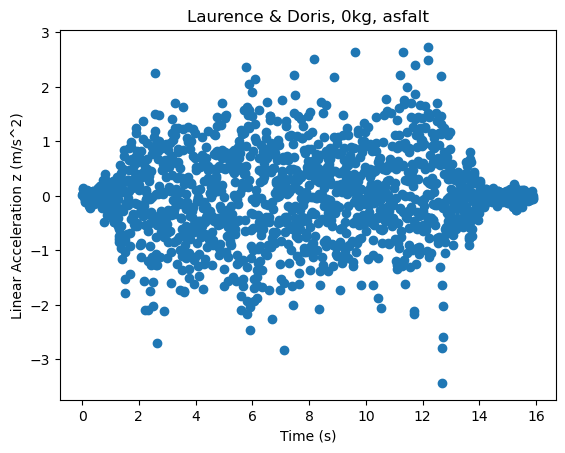

In [11]:
mask = (df_all['makers'] == 'Laurence & Doris') & (df_all['weight'] == 0.0) & (df_all['roadtype'] == 'asphalt')

plt.scatter(
    df_all.loc[mask, 'time'],   # of index als je dat wil
    df_all.loc[mask, 'z']
)

plt.xlabel('Time (s)')
plt.ylabel('Linear Acceleration z (m/s^2)')
plt.title('Laurence & Doris, 0kg, asfalt')

Text(0.5, 1.0, 'servé & jasper, 0kg, asfalt')

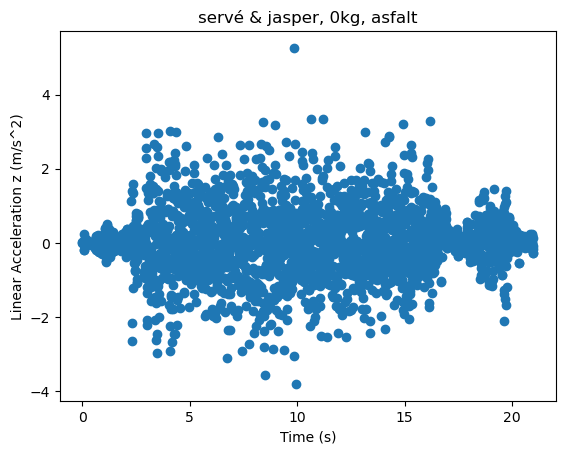

In [12]:
mask = (df_all['makers'] == 'Servé & Jasper') & (df_all['weight'] == 0.0) & (df_all['roadtype'] == 'asphalt')

plt.scatter(
    df_all.loc[mask, 'time'],   # of index als je dat wil
    df_all.loc[mask, 'z']
)
plt.xlabel('Time (s)')
plt.ylabel('Linear Acceleration z (m/s^2)')
plt.title('servé & jasper, 0kg, asfalt')

Text(0.5, 1.0, 'Liz & Renske, 0.75kg, asfalt')

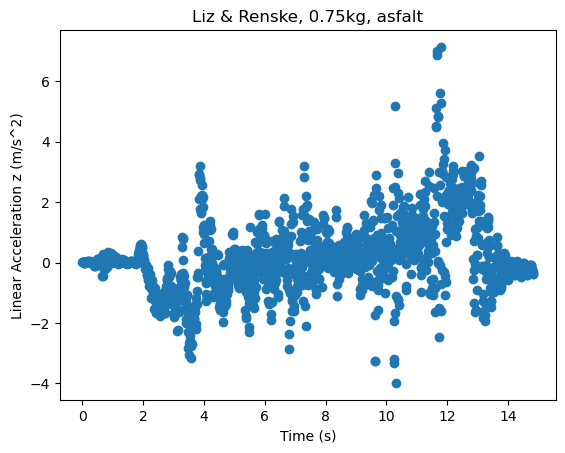

In [13]:
mask = (df_all['makers'] == 'Liz & Renske') & (df_all['weight'] == 0.75) & (df_all['roadtype'] == 'asphalt')

plt.scatter(
    df_all.loc[mask, 'time'],   # of index als je dat wil
    df_all.loc[mask, 'z']
)
plt.xlabel('Time (s)')
plt.ylabel('Linear Acceleration z (m/s^2)')
plt.title('Liz & Renske, 0.75kg, asfalt')

## colummen bedenken 

In [14]:
df_all.to_csv("goedeoutput.csv", index=False)
df_all = pd.read_csv("goedeoutput.csv")
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,second
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0
1,0.015820,-0.783787,-0.178738,0.051753,0.805572,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0
2,0.025869,-0.979383,-0.414515,0.126817,1.071026,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0
3,0.035918,-0.206056,0.006505,0.141417,0.250000,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0
4,0.045967,-0.170787,0.299400,0.056795,0.349334,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0


### x y en z 
- std
- mean
- root mean squared
- 2 andere bedenken

In [15]:
## std
df_all['x_std'] = df_all.groupby(['file'])['x'].transform('std')
df_all['y_std'] = df_all.groupby(['file'])['y'].transform('std')
df_all['z_std'] = df_all.groupby(['file'])['z'].transform('std')

## mean
df_all['x_mean'] = df_all.groupby(['file'])['x'].transform('mean')
df_all['y_mean'] = df_all.groupby(['file'])['y'].transform('mean')
df_all['z_mean'] = df_all.groupby(['file'])['z'].transform('mean')

## rms
df_all['x_rms'] = df_all.groupby(['file'])['x'].transform(lambda x: np.sqrt(np.mean(x**2)))
df_all['y_rms'] = df_all.groupby(['file'])['y'].transform(lambda x: np.sqrt(np.mean(x**2)))
df_all['z_rms'] = df_all.groupby(['file'])['z'].transform(lambda x: np.sqrt(np.mean(x**2)))

df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,second,x_std,y_std,z_std,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0,0.373276,0.169392,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825
1,0.015820,-0.783787,-0.178738,0.051753,0.805572,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0,0.373276,0.169392,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825
2,0.025869,-0.979383,-0.414515,0.126817,1.071026,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0,0.373276,0.169392,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825
3,0.035918,-0.206056,0.006505,0.141417,0.250000,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0,0.373276,0.169392,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825
4,0.045967,-0.170787,0.299400,0.056795,0.349334,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,0,0.373276,0.169392,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825


###### spectral flatness

In [16]:
# Source - https://stackoverflow.com/q/24354279
# Posted by user3765226, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-03, License - CC BY-SA 3.0

from scipy.fft import fft

def spectral_flatness(x): 
    X_f = fft(x) 
    N = len(X_f) 
    magnitude = abs(X_f[:N//2]) 
    geom_mean = np.exp(np.mean(np.log(magnitude + 1e-10)))  # Voeg een kleine waarde toe om log(0) te voorkomen
    aritm_mean = np.mean(magnitude)
    sf = geom_mean / aritm_mean + 1e-10  # Voeg een kleine waarde toe om deling door nul te voorkomen
    return sf


In [17]:
sf = df_all.groupby(['file'])['x'].apply(lambda x: spectral_flatness(x.to_numpy()))
df_all['x_spectral_flatness'] = df_all.groupby(['file'])['x'].transform(lambda x: spectral_flatness(x.to_numpy()))
sf = df_all.groupby(['file'])['y'].apply(lambda x: spectral_flatness(x.to_numpy()))
df_all['y_spectral_flatness'] = df_all.groupby(['file'])['y'].transform(lambda x: spectral_flatness(x.to_numpy()))
sf = df_all.groupby(['file'])['z'].apply(lambda x: spectral_flatness(x.to_numpy()))
df_all['z_spectral_flatness'] = df_all.groupby(['file'])['z'].transform(lambda x: spectral_flatness(x.to_numpy()))

In [18]:
df_all.to_csv("goedeoutput.csv", index=False)
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,z_std,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825,0.522432,0.731454,0.653138
1,0.015820,-0.783787,-0.178738,0.051753,0.805572,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825,0.522432,0.731454,0.653138
2,0.025869,-0.979383,-0.414515,0.126817,1.071026,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825,0.522432,0.731454,0.653138
3,0.035918,-0.206056,0.006505,0.141417,0.250000,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825,0.522432,0.731454,0.653138
4,0.045967,-0.170787,0.299400,0.056795,0.349334,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.06712,-0.002247,-0.00407,0.377403,0.16855,0.139825,0.522432,0.731454,0.653138


# exercise 2

## exploratory data analysis

Text(0.5, 1.0, 'Laurence & Doris, 0kg, asfalt')

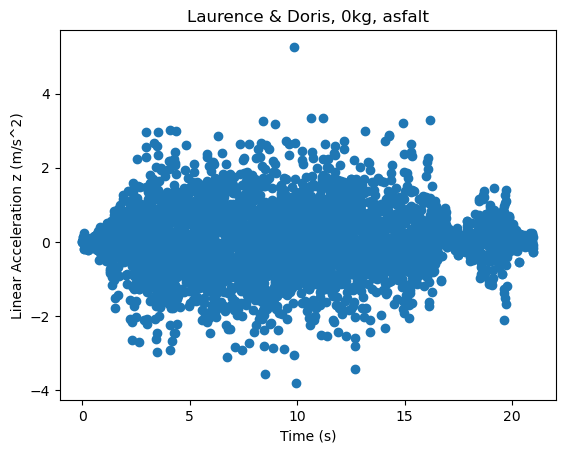

In [19]:
mask = ((df_all['weight'] == 0.0) & (df_all['roadtype'] == 'asphalt'))

plt.scatter(
    df_all.loc[mask, 'time'],   # of index als je dat wil
    df_all.loc[mask, 'z']
)

plt.xlabel('Time (s)')
plt.ylabel('Linear Acceleration z (m/s^2)')
plt.title('Laurence & Doris, 0kg, asfalt')

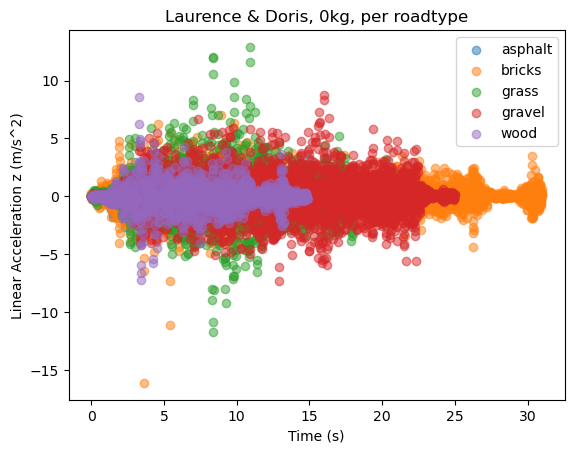

In [20]:
import matplotlib.pyplot as plt

# filter alleen weight = 0.0
df_filtered = df_all[df_all['weight'] == 0.0]

for roadtype, groep in df_filtered.groupby('roadtype'):
    plt.scatter(
        groep['time'],
        groep['z'],
        label=roadtype   # zorgt voor legenda
        , alpha=0.5  # maakt de punten iets transparant zodat ze beter zichtbaar zijn bij overlap
    )

plt.xlabel('Time (s)')
plt.ylabel('Linear Acceleration z (m/s^2)')
plt.title('Laurence & Doris, 0kg, per roadtype')

plt.legend()
plt.show()

<Axes: xlabel='roadtype', ylabel='z'>

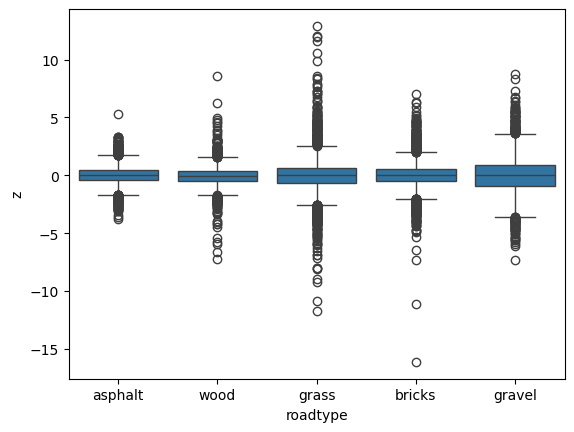

In [21]:
sns.boxplot(x='roadtype', y='z', data=df_all[df_all['weight'] == 0.0])

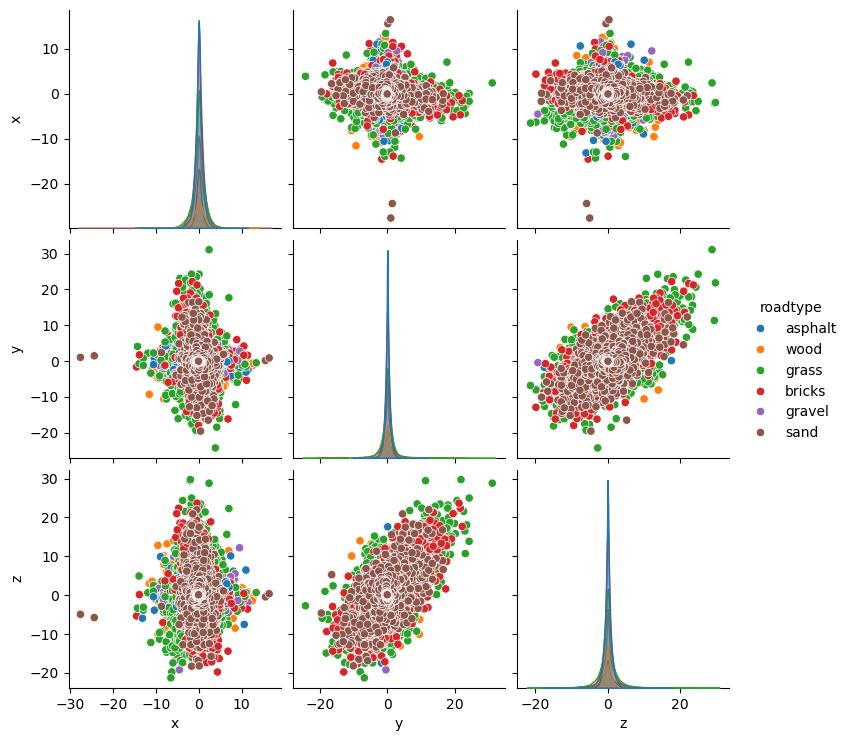

In [22]:
sns.pairplot(df_all, hue='roadtype', vars=['x', 'y', 'z'])

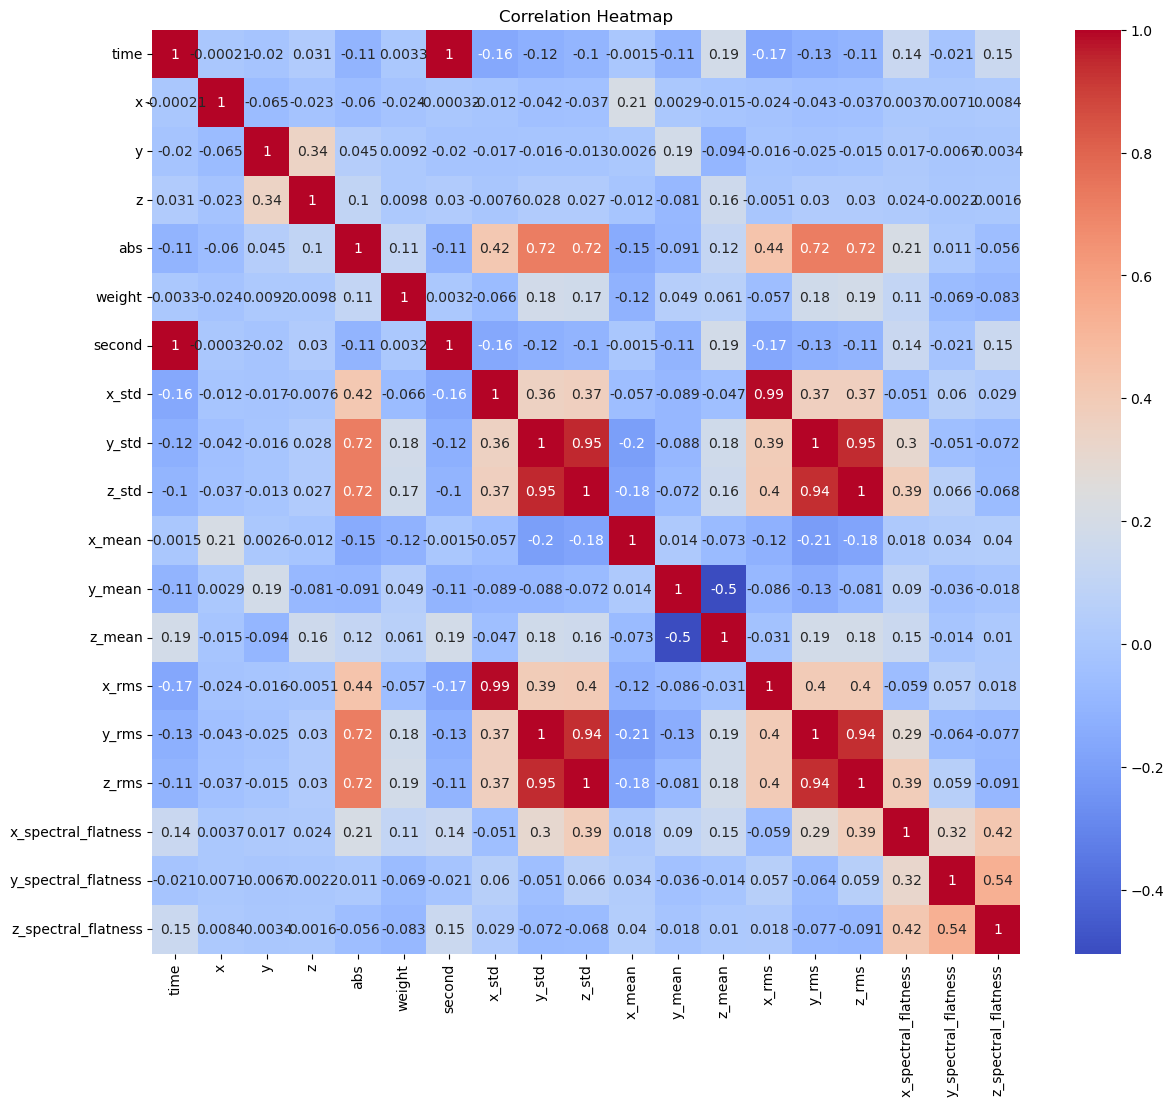

In [39]:
plt.figure(figsize=(14, 12))
sns.heatmap(df_all.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_all.select_dtypes(include='number')  # alleen numerieke kolommen

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data[vif_data['VIF'] > 5])

                feature          VIF
0                  time  1733.773175
6                second  1628.003878
7                 x_std   338.022792
8                 y_std   532.965373
9                 z_std   446.340707
13                x_rms   352.836984
14                y_rms   524.025941
15                z_rms   465.705810
16  x_spectral_flatness    38.275795
17  y_spectral_flatness    47.941408
18  z_spectral_flatness    75.101037


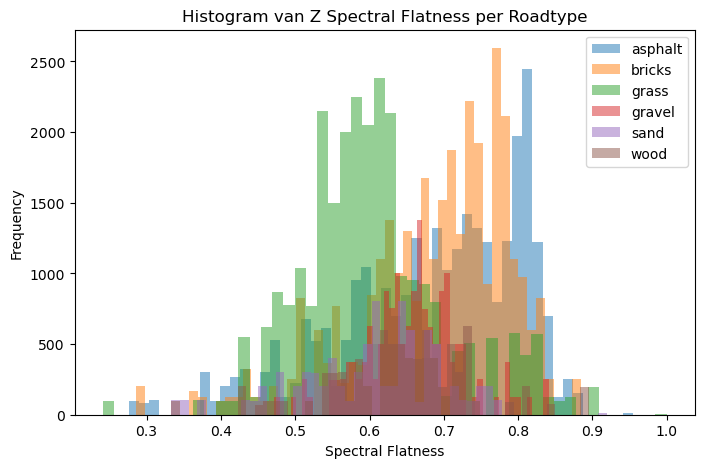

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for roadtype, groep in df_all.groupby('roadtype'):
    plt.hist(
        groep['z_spectral_flatness'],
        bins=50,
        alpha=0.5,
        label=roadtype
    )

plt.xlabel('Spectral Flatness')
plt.ylabel('Frequency')
plt.title('Histogram van Z Spectral Flatness per Roadtype')
plt.legend()
plt.show()


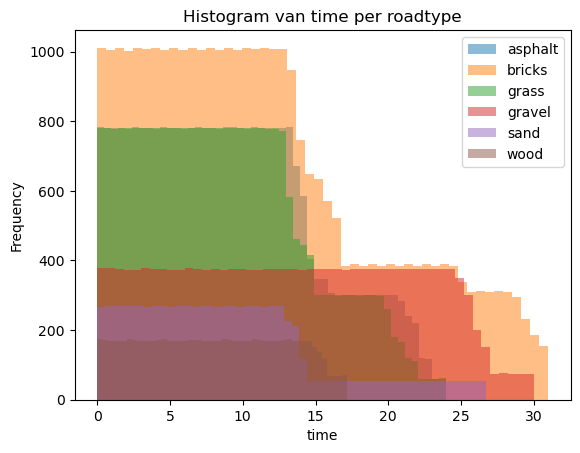

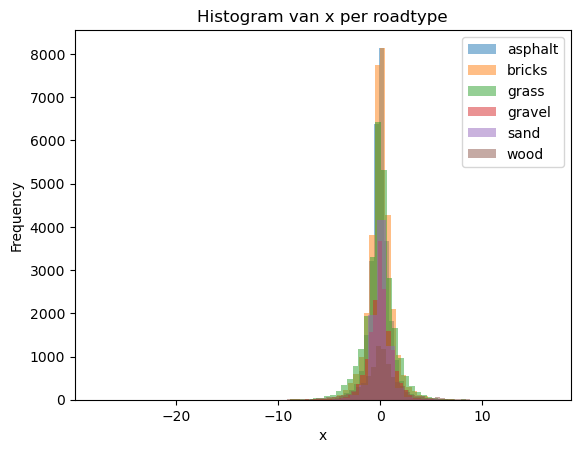

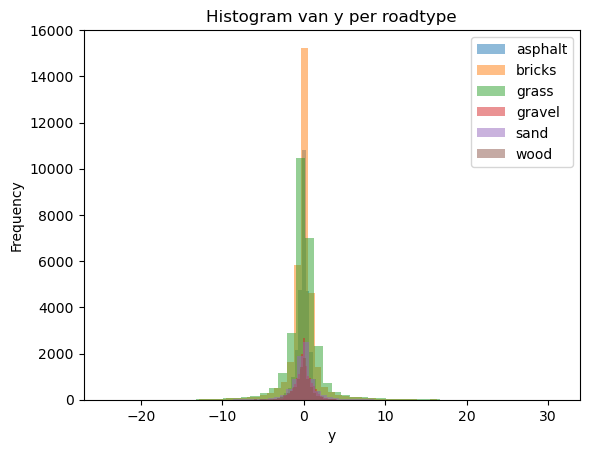

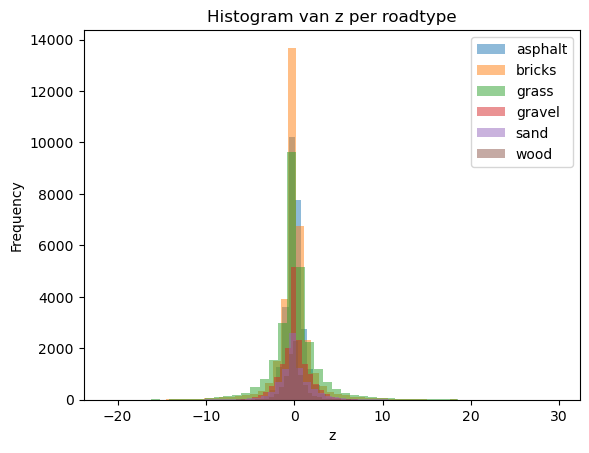

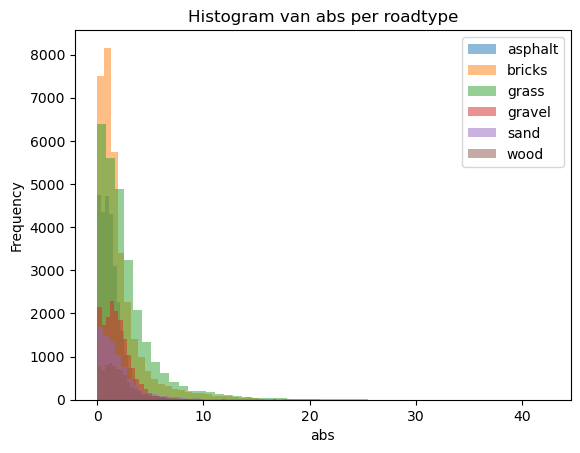

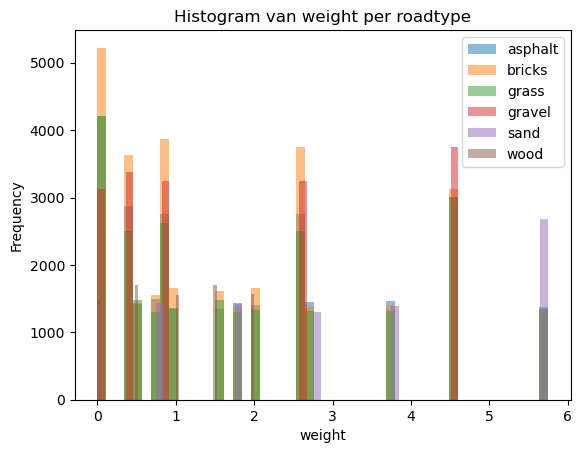

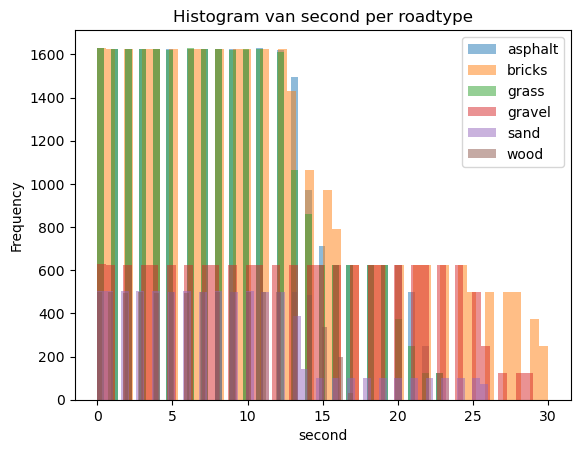

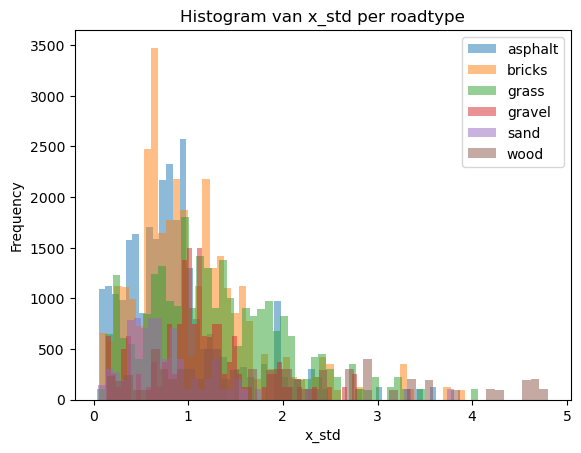

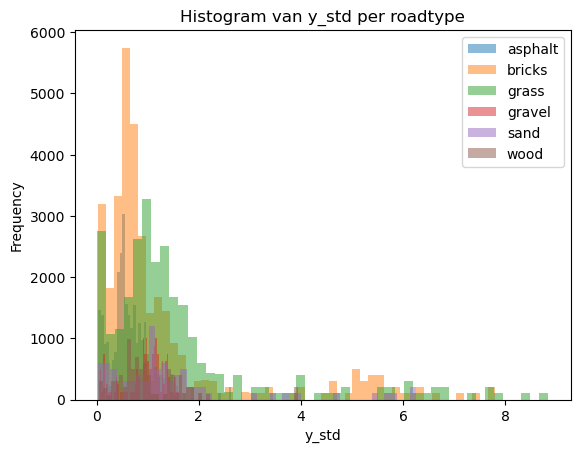

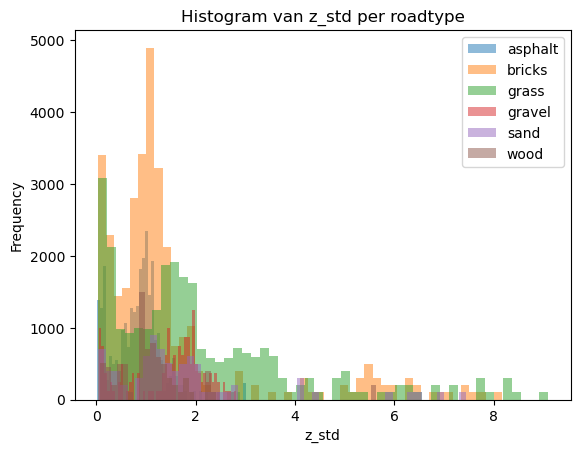

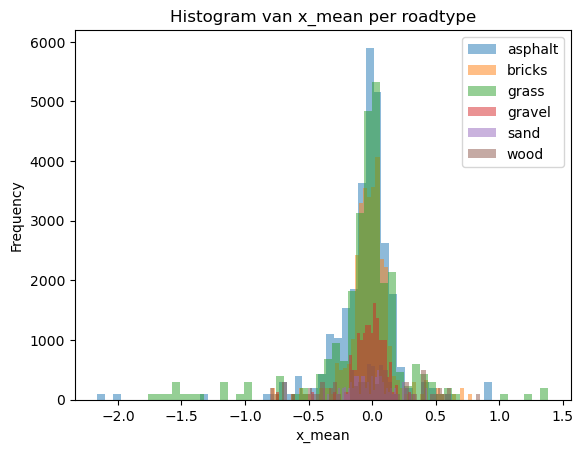

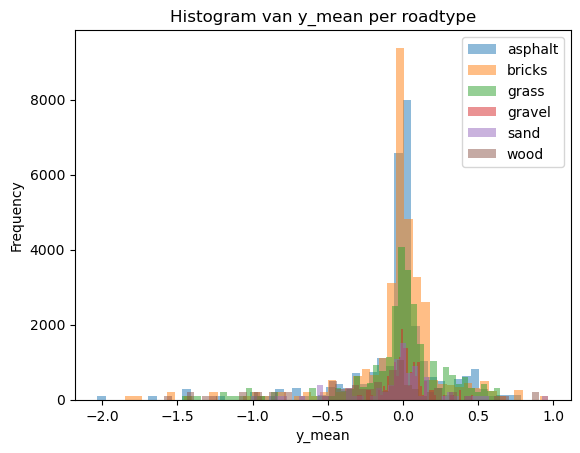

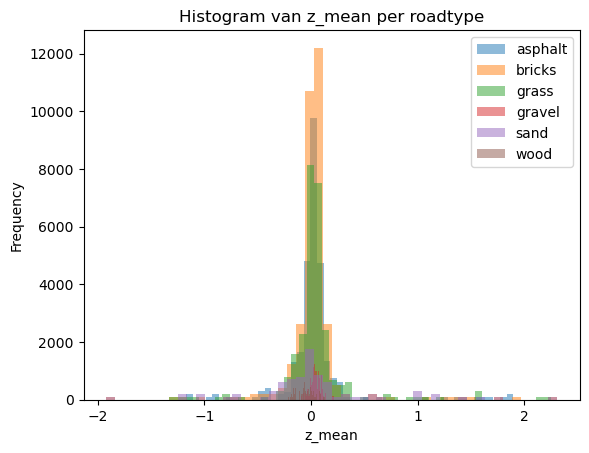

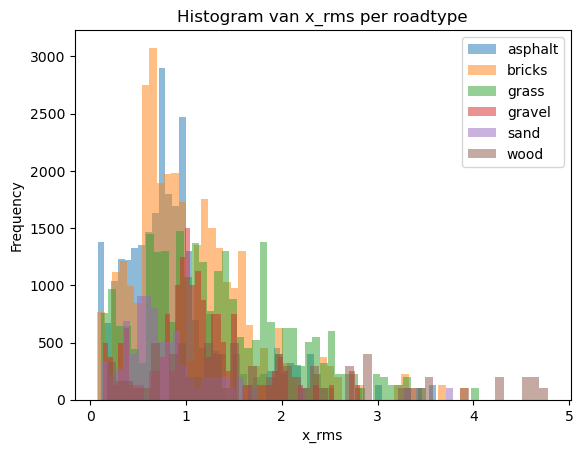

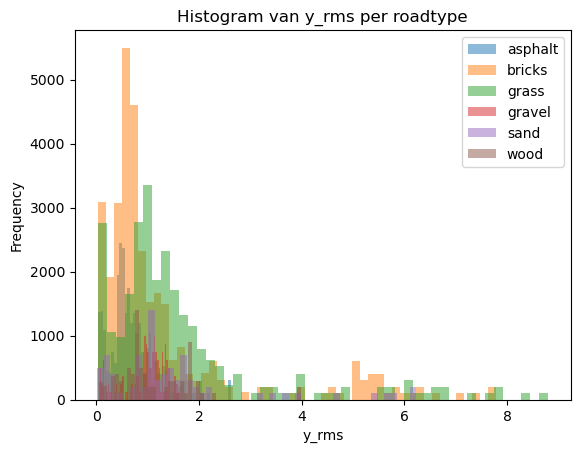

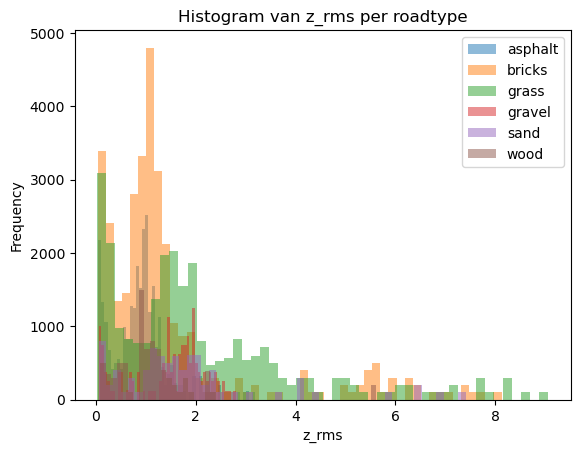

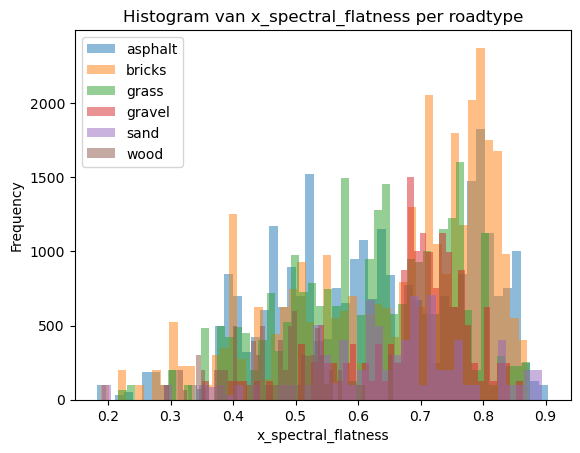

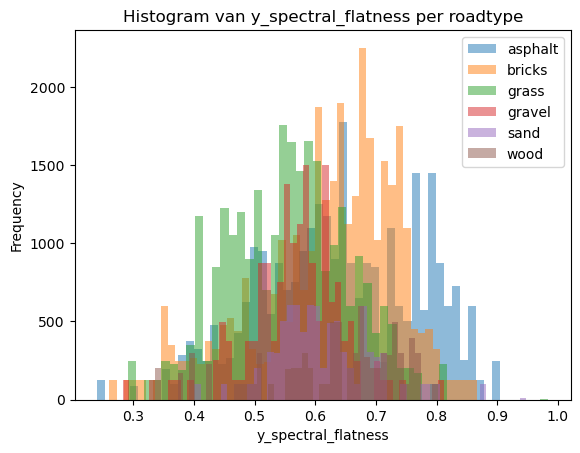

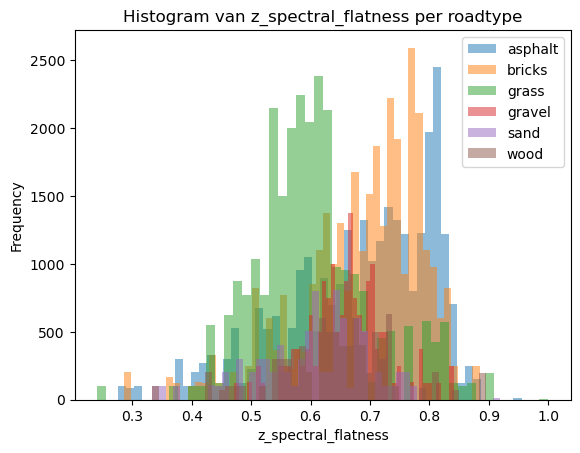

In [28]:
import matplotlib.pyplot as plt

for feature in df_all.columns:
    if df_all[feature].dtype in ['int64', 'float64']:

        plt.figure()  # nieuwe plot per feature

        for roadtype, groep in df_all.groupby('roadtype'):
            plt.hist(
                groep[feature],
                bins=50,
                alpha=0.5,
                label=roadtype
            )

        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.title(f'Histogram van {feature} per roadtype')

        plt.legend()
        plt.show()

## start modeleren

### train/test set + dummie variable

In [46]:
df_all = df_all.drop_duplicates(subset='file')
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,z_std,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.575868,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.916088,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.862473,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.736694,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434
